In [ ]:
# =========================================
# 4.1 DATA CLEANING & PREPARATION
# =========================================

import pandas as pd

# load dataset
df = pd.read_excel("edited data TA.xlsx")

# konversi kolom tanggal ke datetime
df['Tanggal Job'] = pd.to_datetime(df['Tanggal Job'])

# cek missing value
print("Missing Value:\n", df.isnull().sum())

# agregasi dari transaksi → harian
df_daily = df.groupby('Tanggal Job')['Jumlah Cylinder'].sum()

# ubah ke mingguan
df_weekly = df_daily.resample('W').sum()

# isi missing value (jika ada)
df_weekly = df_weekly.ffill()

# cek hasil akhir
print("\nJumlah data weekly:", len(df_weekly))
print(df_weekly.head())

Missing Value:
 Tanggal Job        0
Jumlah Cylinder    0
dtype: int64

Jumlah data weekly: 53
Tanggal Job
2025-01-05    106
2025-01-12    147
2025-01-19    181
2025-01-26    173
2025-02-02    169
Freq: W-SUN, Name: Jumlah Cylinder, dtype: int64


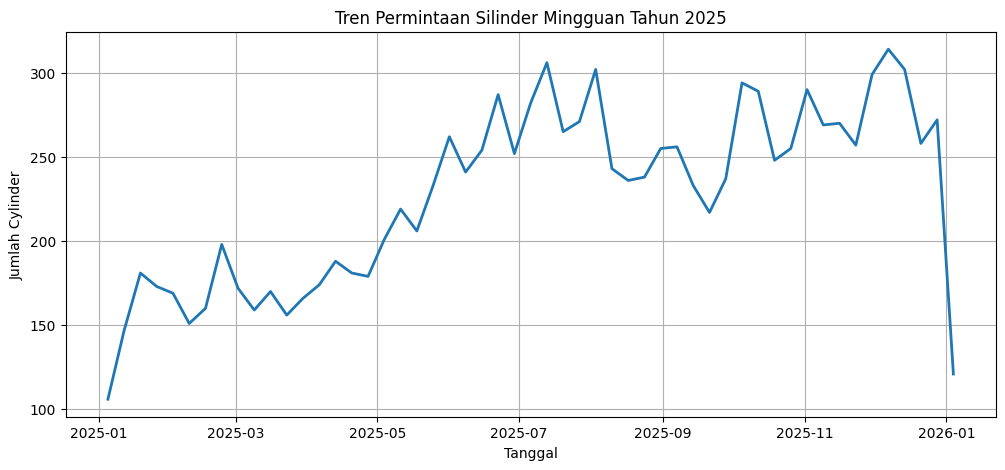

In [ ]:
# =========================================
# 4.2.1 VISUALISASI TREND DATA
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_weekly.index, df_weekly, linewidth=2)

plt.title("Tren Permintaan Silinder Mingguan Tahun 2025")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Cylinder")
plt.grid(True)

plt.show()

In [ ]:
# =========================================
# 4.2.2 DESCRIPTIVE STATISTICS
# =========================================

df_weekly.describe()

,Jumlah Cylinder
count,53.000000
mean,227.622642
std,53.305082
min,106.000000
25%,179.000000
50%,238.000000
75%,269.000000
max,314.000000


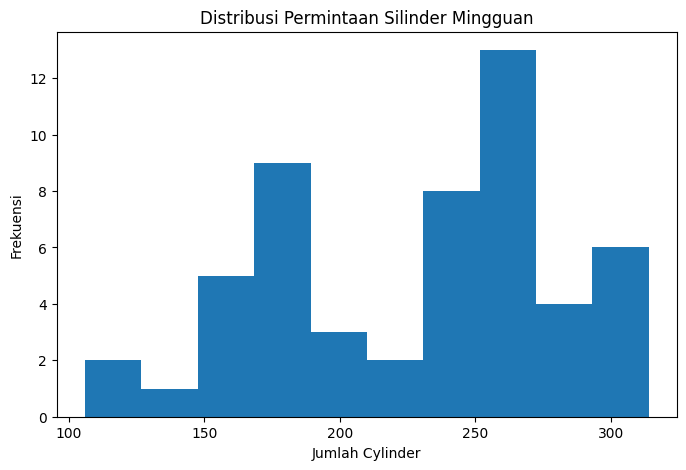

In [ ]:
# =========================================
# 4.2.3 DISTRIBUSI DATA
# =========================================

plt.figure(figsize=(8,5))
plt.hist(df_weekly, bins=10)

plt.title("Distribusi Permintaan Silinder Mingguan")
plt.xlabel("Jumlah Cylinder")
plt.ylabel("Frekuensi")

plt.show()

In [ ]:
# =========================================
# 4.3 SPLIT DATA
# =========================================

train_size = int(len(df_weekly) * 0.8)

train = df_weekly.iloc[:train_size]
test = df_weekly.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 42
Test size: 11


In [ ]:
# =========================================
# 4.4 BASELINE MODEL
# =========================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# NAIVE MODEL
# -------------------------
history = train.tolist()
naive_pred = []

for t in range(len(test)):
    yhat = history[-1]
    naive_pred.append(yhat)
    history.append(test.iloc[t])

# -------------------------
# MOVING AVERAGE
# -------------------------
window = 3

history = train.tolist()
ma_pred = []

for t in range(len(test)):
    yhat = np.mean(history[-window:])
    ma_pred.append(yhat)
    history.append(test.iloc[t])

# -------------------------
# EVALUASI
# -------------------------
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100
    return mae, rmse, mape

naive_mae, naive_rmse, naive_mape = evaluate(test, naive_pred)
ma_mae, ma_rmse, ma_mape = evaluate(test, ma_pred)

print("Naive:", naive_mae, naive_rmse, naive_mape)
print("MA   :", ma_mae, ma_rmse, ma_mape)

Naive: 32.27272727272727 51.30213534453601 17.985599250244164
MA   : 34.57575757575757 53.387756323454205 19.03798081682672


In [ ]:
# =========================================
# 4.5 MODEL ARIMA
# =========================================

from statsmodels.tsa.arima.model import ARIMA

# training
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# prediksi
arima_pred = model_fit.forecast(steps=len(test))

# evaluasi
arima_mae, arima_rmse, arima_mape = evaluate(test, arima_pred)

print("ARIMA:", arima_mae, arima_rmse, arima_mape)

ARIMA: 32.11029883411272 49.69391893045363 16.910274036308657


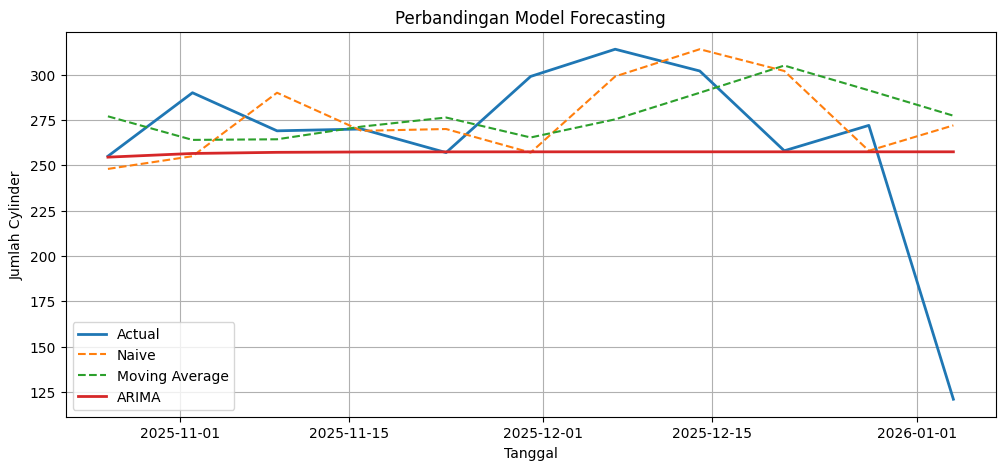

In [ ]:
# =========================================
# 4.6 PERBANDINGAN MODEL
# =========================================

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, naive_pred, "--", label="Naive")
plt.plot(test.index, ma_pred, "--", label="Moving Average")
plt.plot(test.index, arima_pred, label="ARIMA", linewidth=2)

plt.title("Perbandingan Model Forecasting")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Cylinder")
plt.legend()
plt.grid(True)

plt.show()

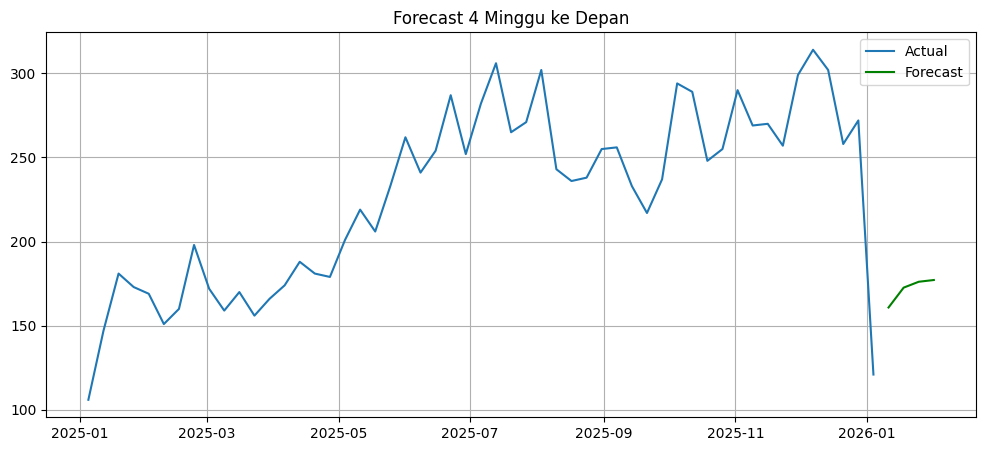

In [ ]:
# =========================================
# 4.7 FORECAST MASA DEPAN
# =========================================

final_model = ARIMA(df_weekly, order=(1,1,1))
final_fit = final_model.fit()

future = final_fit.forecast(steps=4)

# visualisasi
plt.figure(figsize=(12,5))
plt.plot(df_weekly.index, df_weekly, label="Actual")
plt.plot(future.index, future, label="Forecast", color="green")

plt.title("Forecast 4 Minggu ke Depan")
plt.legend()
plt.grid(True)

plt.show()


EDA PICT

In [ ]:
df_weekly.describe()

,Jumlah Cylinder
count,53.000000
mean,227.622642
std,53.305082
min,106.000000
25%,179.000000
50%,238.000000
75%,269.000000
max,314.000000


In [ ]:
table = desc.rename({
    'count': 'Jumlah Data',
    'mean': 'Rata-rata',
    'std': 'Standar Deviasi',
    'min': 'Minimum',
    '25%': 'Kuartil 1',
    '50%': 'Median',
    '75%': 'Kuartil 3',
    'max': 'Maksimum'
})

df_table = table.to_frame(name='Nilai')

df_table.to_excel("statistik_deskriptif.xlsx")

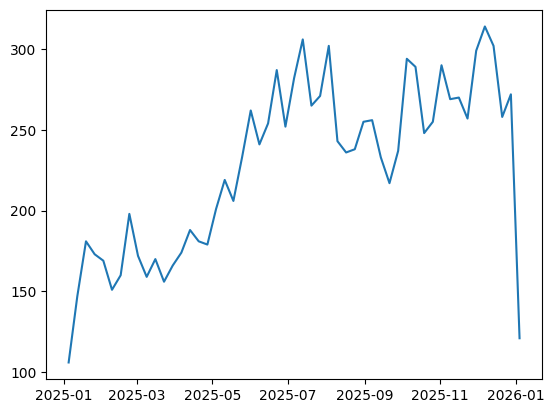

In [ ]:
plt.plot(df_weekly.index, df_weekly)